In [ ]:
# ── Imports e configurações ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download('punkt_tab')

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

PROCESSED = Path("../data/processed")
PROCESSED.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
## import subprocess (RODAR SOMENTE SE O SCRIPT NÃO TIVER SIDO GERADO AINDA!)
from pathlib import Path

if not Path("../data/raw/reviews.csv").exists():
    print("Dados não encontrados. Gerando dataset...")
    subprocess.run(["python", "collect_data.py"], cwd="../scripts", check=True)
    print("Dataset gerado!") 

In [4]:
# ── Carregar e pré-processar dados ────────────────────────────────────────────
import sys
sys.path.append("../scripts")
from preprocess import preprocess

df_raw = pd.read_csv("../data/raw/reviews.csv")
df     = preprocess(df_raw)

print(f"Dataset: {len(df)} reviews")
print(f"\nDistribuição de sentimentos:")
print(df["sentiment_label"].value_counts())
print(f"\nDistribuição de ratings:")
print(df["rating"].value_counts().sort_index())
df.head(3)

Dataset: 247 reviews

Distribuição de sentimentos:
sentiment_label
positive    108
neutral      75
negative     64
Name: count, dtype: int64

Distribuição de ratings:
rating
1    32
2    32
3    75
4    47
5    61
Name: count, dtype: int64


,review_id,category,rating,review_text,sentiment_label,helpful_votes,verified_purchase,review_date,clean_text,processed_text,text_length,word_count,review_month,review_year
0,R00034,Electronics,3,Decent product for the price. Does what it's s...,neutral,3,False,2023-08-19,decent product for the price does what its sup...,decent product price supposed,60,11,8,2023
1,R00007,Electronics,5,"Excellent quality, fast delivery. Exactly as d...",positive,43,True,2023-02-28,excellent quality fast delivery exactly as des...,excellent quality fast delivery exactly descri...,73,9,2,2023
2,R00182,Clothing,3,Reasonable purchase. Material is okay but not ...,neutral,16,True,2023-10-30,reasonable purchase material is okay but not o...,reasonable purchase material okay outstanding,58,8,10,2023


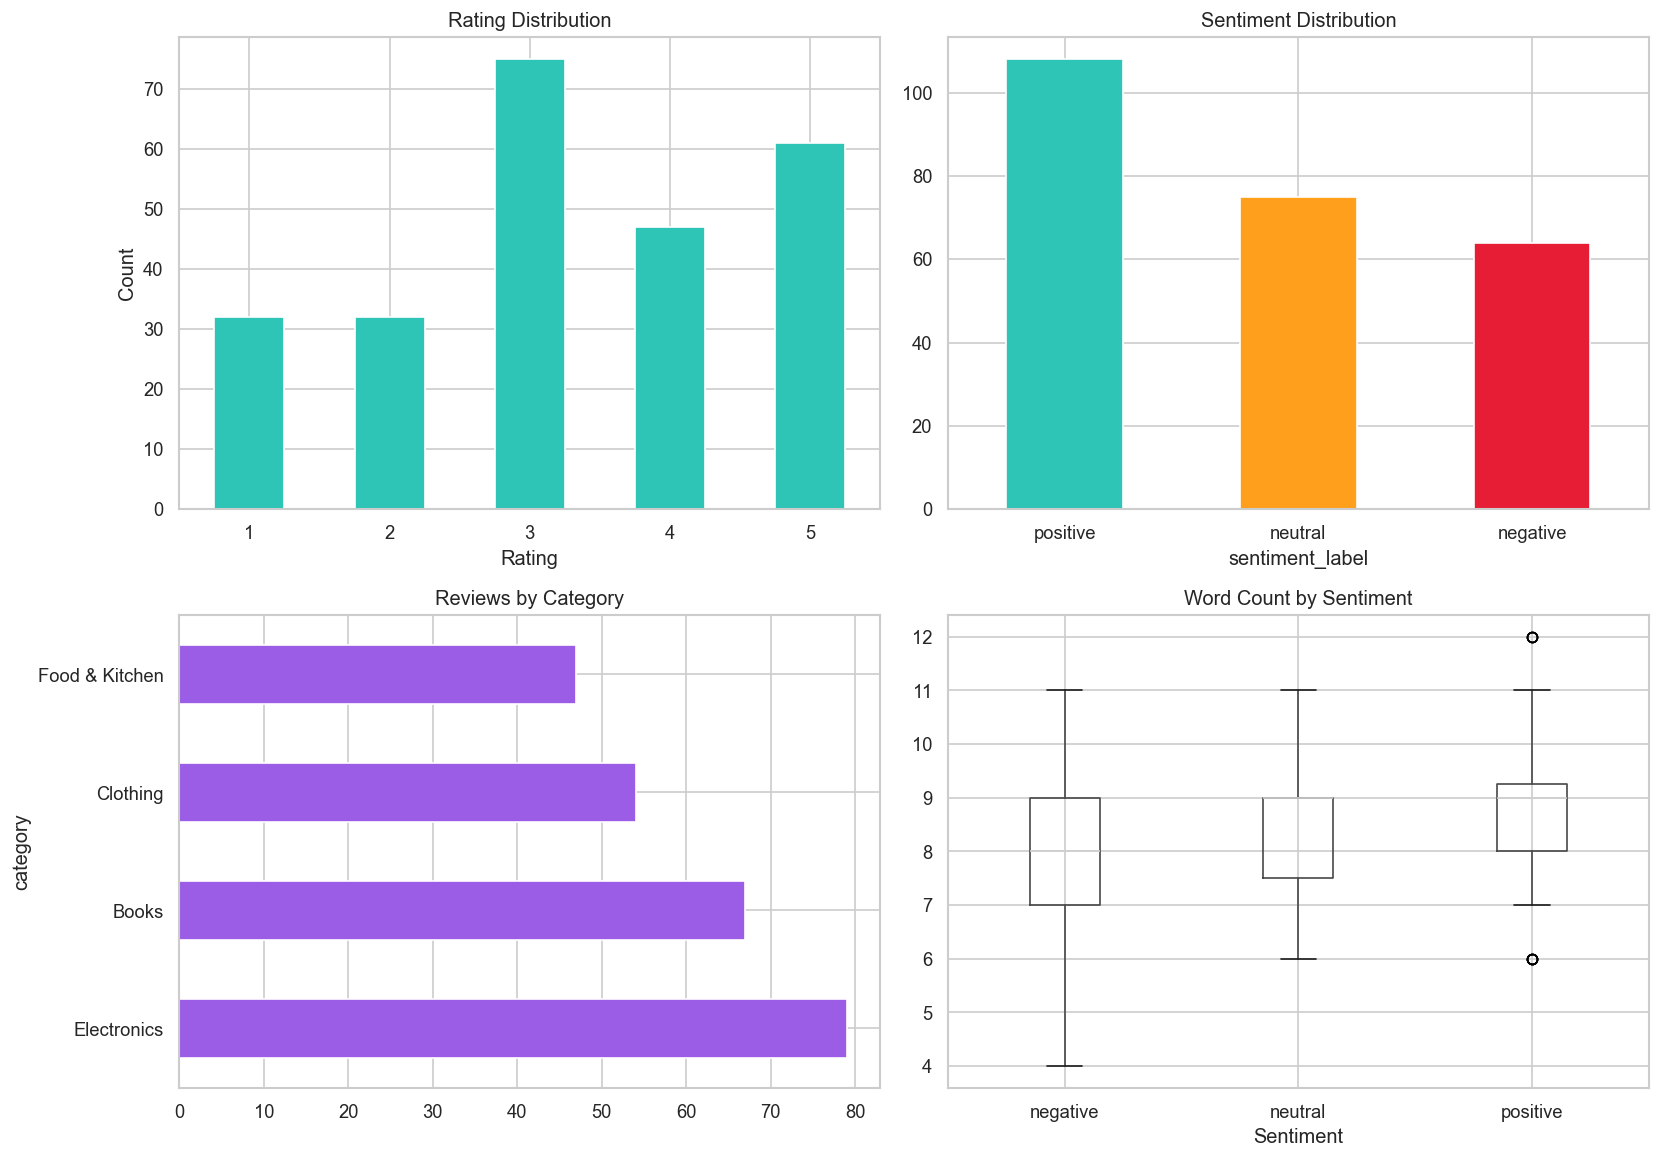

In [5]:
# ── Análise exploratória ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0,0], color="#2EC4B6", edgecolor="white")
axes[0,0].set_title("Rating Distribution")
axes[0,0].set_xlabel("Rating")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis="x", rotation=0)

# Sentiment distribution
df["sentiment_label"].value_counts().plot(
    kind="bar", ax=axes[0,1], color=["#2EC4B6", "#FF9F1C", "#E71D36"], edgecolor="white")
axes[0,1].set_title("Sentiment Distribution")
axes[0,1].tick_params(axis="x", rotation=0)

# Reviews por categoria
df["category"].value_counts().plot(
    kind="barh", ax=axes[1,0], color="#9B5DE5")
axes[1,0].set_title("Reviews by Category")

# Word count por sentimento
df.boxplot(column="word_count", by="sentiment_label", ax=axes[1,1])
axes[1,1].set_title("Word Count by Sentiment")
axes[1,1].set_xlabel("Sentiment")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../outputs/eda.png", dpi=150, bbox_inches="tight")
plt.show()

VADER Accuracy vs ground truth: 75.71%


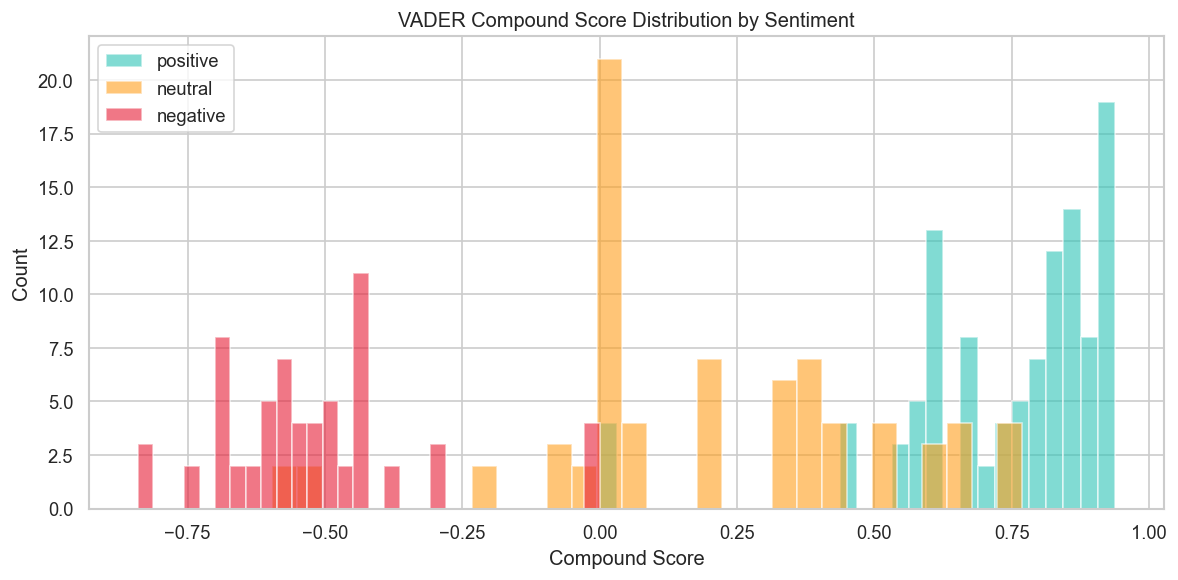

In [6]:
# ── Análise de sentimento com VADER ──────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

df["vader_scores"] = df["review_text"].apply(lambda x: sia.polarity_scores(x))
df["vader_compound"] = df["vader_scores"].apply(lambda x: x["compound"])
df["vader_sentiment"] = df["vader_compound"].apply(
    lambda x: "positive" if x >= 0.05 else ("negative" if x <= -0.05 else "neutral")
)

# Comparar VADER com labels reais
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(df["sentiment_label"], df["vader_sentiment"])
print(f"VADER Accuracy vs ground truth: {accuracy:.2%}")

# Distribuição dos scores VADER por sentimento real
fig, ax = plt.subplots(figsize=(10, 5))
for sentiment, color in zip(["positive", "neutral", "negative"], ["#2EC4B6", "#FF9F1C", "#E71D36"]):
    subset = df[df["sentiment_label"] == sentiment]["vader_compound"]
    ax.hist(subset, bins=30, alpha=0.6, label=sentiment, color=color)
ax.set_title("VADER Compound Score Distribution by Sentiment")
ax.set_xlabel("Compound Score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/vader_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

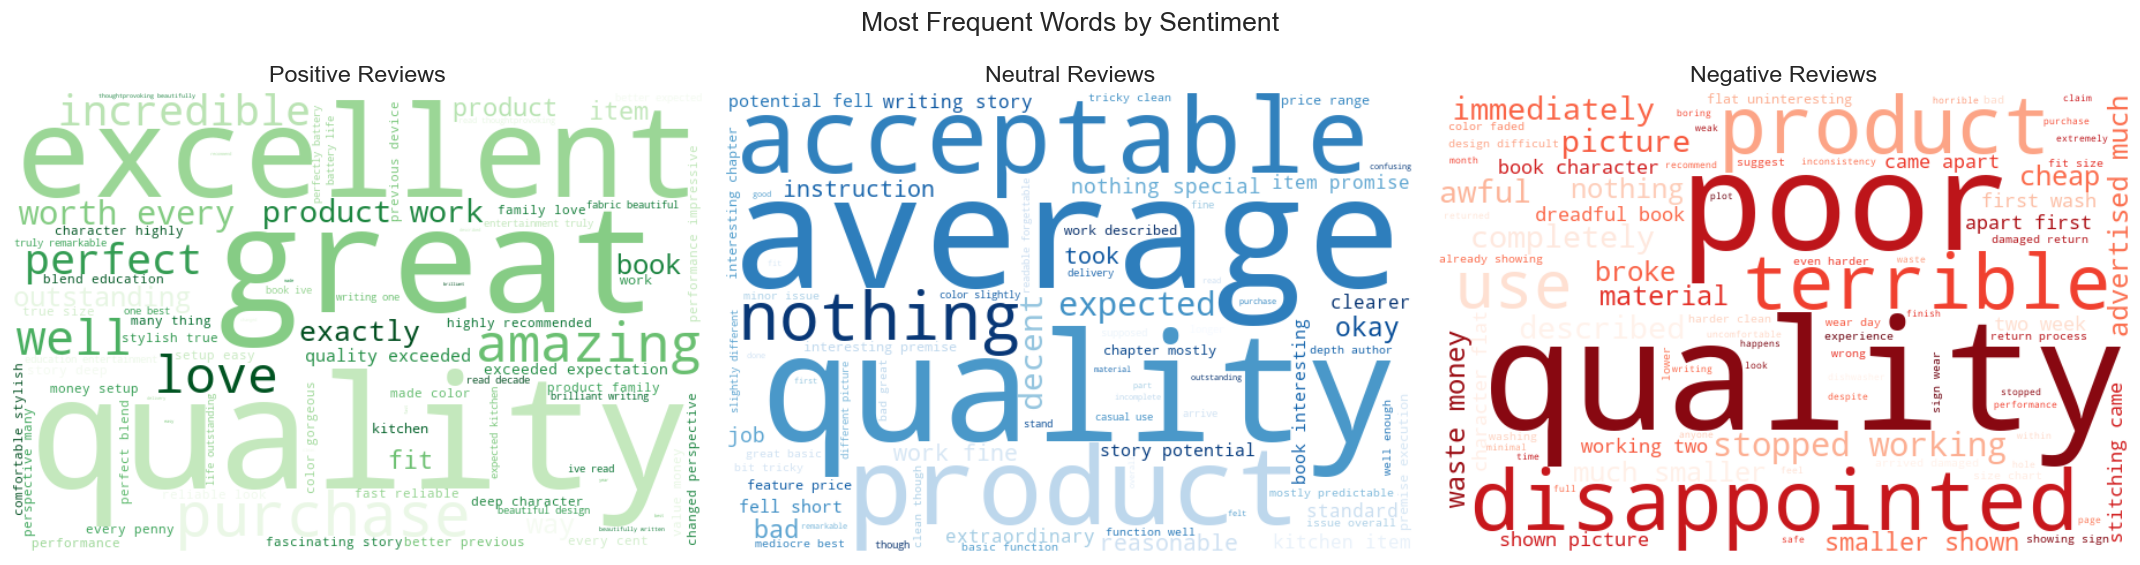

In [7]:
# ── Word Clouds por sentimento ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments   = ["positive", "neutral", "negative"]
colors_wc    = ["Greens", "Blues", "Reds"]

for ax, sentiment, colormap in zip(axes, sentiments, colors_wc):
    text = " ".join(df[df["sentiment_label"] == sentiment]["processed_text"].dropna())
    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap=colormap,
        max_words=80
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sentiment.capitalize()} Reviews", fontsize=14)

plt.suptitle("Most Frequent Words by Sentiment", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

── Top words per topic ──
Topic 1: quality | decent | first | way | highly | item | picture | price | described | poor
Topic 2: book | purchase | changed | could | page | brilliant | best | clearer | instruction | uninteresting
Topic 3: quality | written | excellent | well | color | purchase | nothing | material | read | product
Topic 4: kitchen | love | product | expected | average | worth | much | every | nothing | work
Topic 5: quality | acceptable | great | product | outstanding | price | amazing | bad | overall | buy


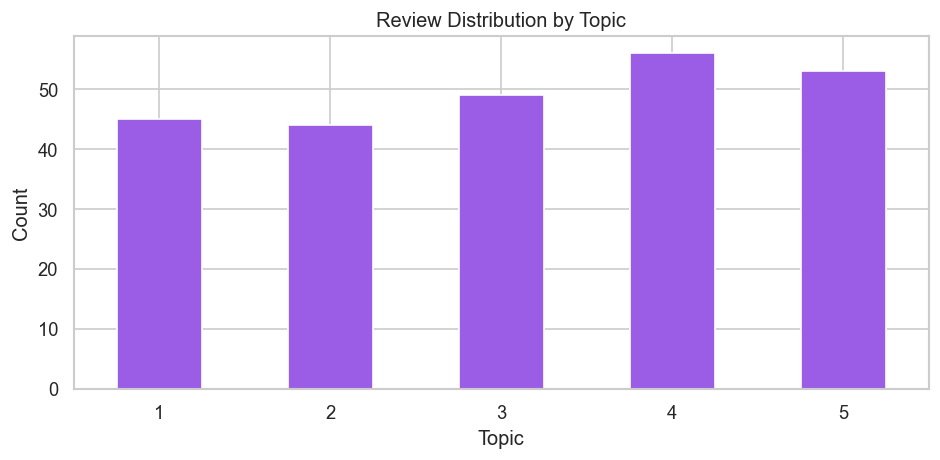

In [8]:
# ── Topic Modeling com LDA ────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(df["processed_text"].dropna())

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda.fit(X_tfidf)

# Exibir top palavras por tópico
feature_names = tfidf.get_feature_names_out()
print("── Top words per topic ──")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {idx+1}: {' | '.join(top_words)}")

# Atribuir tópico dominante a cada review
df_valid = df.dropna(subset=["processed_text"]).copy()
topic_dist = lda.transform(tfidf.transform(df_valid["processed_text"]))
df_valid["dominant_topic"] = topic_dist.argmax(axis=1) + 1

fig, ax = plt.subplots(figsize=(8, 4))
df_valid["dominant_topic"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#9B5DE5", edgecolor="white")
ax.set_title("Review Distribution by Topic")
ax.set_xlabel("Topic")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../outputs/topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

── Classification Report ──
              precision    recall  f1-score   support

    negative       1.00      0.92      0.96        13
    positive       0.96      1.00      0.98        22

    accuracy                           0.97        35
   macro avg       0.98      0.96      0.97        35
weighted avg       0.97      0.97      0.97        35



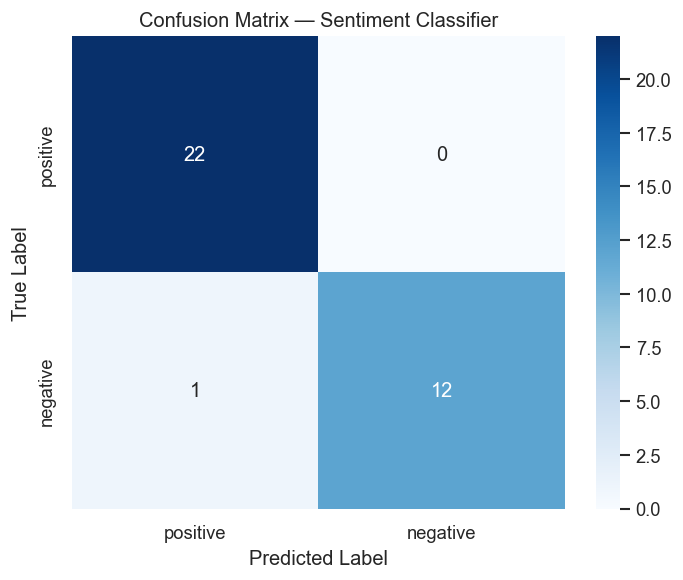

In [9]:
# ── Modelo de classificação de sentimento ────────────────────────────────────
df_model = df.dropna(subset=["processed_text"]).copy()
df_model = df_model[df_model["sentiment_label"] != "neutral"]  # binário: pos vs neg

X = tfidf.fit_transform(df_model["processed_text"])
y = df_model["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("── Classification Report ──")
print(classification_report(y_test, y_pred))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=["positive", "negative"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["positive", "negative"],
            yticklabels=["positive", "negative"], ax=ax)
ax.set_title("Confusion Matrix — Sentiment Classifier")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Salvar dados processados para Power BI ────────────────────────────────────
# Adiciona scores VADER ao dataset principal
df_export = df_valid.copy()
df_export["vader_sentiment"] = df_export["vader_compound"].apply(
    lambda x: "positive" if x >= 0.05 else ("negative" if x <= -0.05 else "neutral")
)

# Resumo por categoria
category_summary = (
    df_export.groupby("category")
    .agg(
        total_reviews=("review_id", "count"),
        avg_rating=("rating", "mean"),
        avg_vader=("vader_compound", "mean"),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean() * 100),
    )
    .round(2)
    .reset_index()
)

# Resumo por mês
monthly_summary = (
    df_export.groupby(["review_year", "review_month"])
    .agg(
        total_reviews=("review_id", "count"),
        avg_rating=("rating", "mean"),
        avg_vader=("vader_compound", "mean"),
    )
    .round(2)
    .reset_index()
)

df_export.to_csv(PROCESSED / "reviews_final.csv",         index=False, encoding="utf-8-sig")
category_summary.to_csv(PROCESSED / "category_summary.csv", index=False, encoding="utf-8-sig")
monthly_summary.to_csv(PROCESSED / "monthly_summary.csv",   index=False, encoding="utf-8-sig")

print("Files saved!")
print(f"  reviews_final:    {len(df_export):,} rows")
print(f"  category_summary: {len(category_summary)} rows")
print(f"  monthly_summary:  {len(monthly_summary)} rows")
print("\nCategory Summary:")
print(category_summary.to_string(index=False))

Files saved!
  reviews_final:    247 rows
  category_summary: 4 rows
  monthly_summary:  12 rows

Category Summary:
      category  total_reviews  avg_rating  avg_vader  pct_positive  pct_negative
         Books             67        3.46       0.28         47.76         20.90
      Clothing             54        3.15       0.22         44.44         31.48
   Electronics             79        3.29       0.22         39.24         25.32
Food & Kitchen             47        3.23       0.30         44.68         27.66
